## Visualizes BayesWave reconstruction results across multiple experiments

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
#from gwpy.timeseries import TimeSeries
#from gwpy.frequencyseries import FrequencySerie
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

sns.set(style='whitegrid', context='paper', font_scale=1.8)

: 

In [2]:
def load_time_domain_data(filepath):
    """Load time domain data from BayesWave output files.
    
    Parameters
    ----------
    filepath : str or Path
        Path to the data file
    
    Returns
    -------
    np.ndarray
        Array with shape (N, 2) containing [time, strain] columns
    """
    with open(filepath, 'r') as f:
        for line in f:
            if line.strip() == '---------------':
                break
        next(f)
        data = []
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                data.append([float(parts[0]), float(parts[1])])
    
    return np.array(data)


def load_psd_data(filepath):
    """Load power spectral density data from BayesWave output files.
    
    Parameters
    ----------
    filepath : str or Path
        Path to the PSD data file
    
    Returns
    -------
    np.ndarray
        Array with shape (N, 2) containing [frequency, PSD] columns
    """
    with open(filepath, 'r') as f:
        for line in f:
            if line.strip() == '---------------':
                break
        next(f)
        data = []
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                data.append([float(parts[0]), float(parts[1])])
    
    return np.array(data)

In [3]:
# Experiment parameters
durations = ['04s', '08s', '16s', '32s']
amplitudes = ['1.25', '2.50', '5.00']
base_path = Path('/anvil/scratch/x-ctirapongpra/gw-collapsar/Frames')

In [4]:
def load_likelihood_chains(filepath, burnin_frac=0.1):
    """Load BayesWave likelihood chains from output file.
    
    Parameters
    ----------
    filepath : str or Path
        Path to the all_chain_likelihoods.txt file
    burnin_frac : float, optional
        Fraction of samples to discard as burn-in (default: 0.1 = 10%)
    
    Returns
    -------
    iterations : np.ndarray
        Array of iteration numbers
    chains : np.ndarray
        Array with shape (n_iterations, n_chains) containing log-likelihood values
    chains_postburnin : np.ndarray
        Chains after removing burn-in
    """
    # Load the data, skipping the header
    data = np.loadtxt(filepath, skiprows=1)
    
    # First column is iteration number, rest are chains
    iterations = data[:, 0]
    chains = data[:, 1:]
    
    # Remove burn-in
    burnin_idx = int(len(iterations) * burnin_frac)
    chains_postburnin = chains[burnin_idx:]
    iterations_postburnin = iterations[burnin_idx:]
    
    return iterations, chains, iterations_postburnin, chains_postburnin

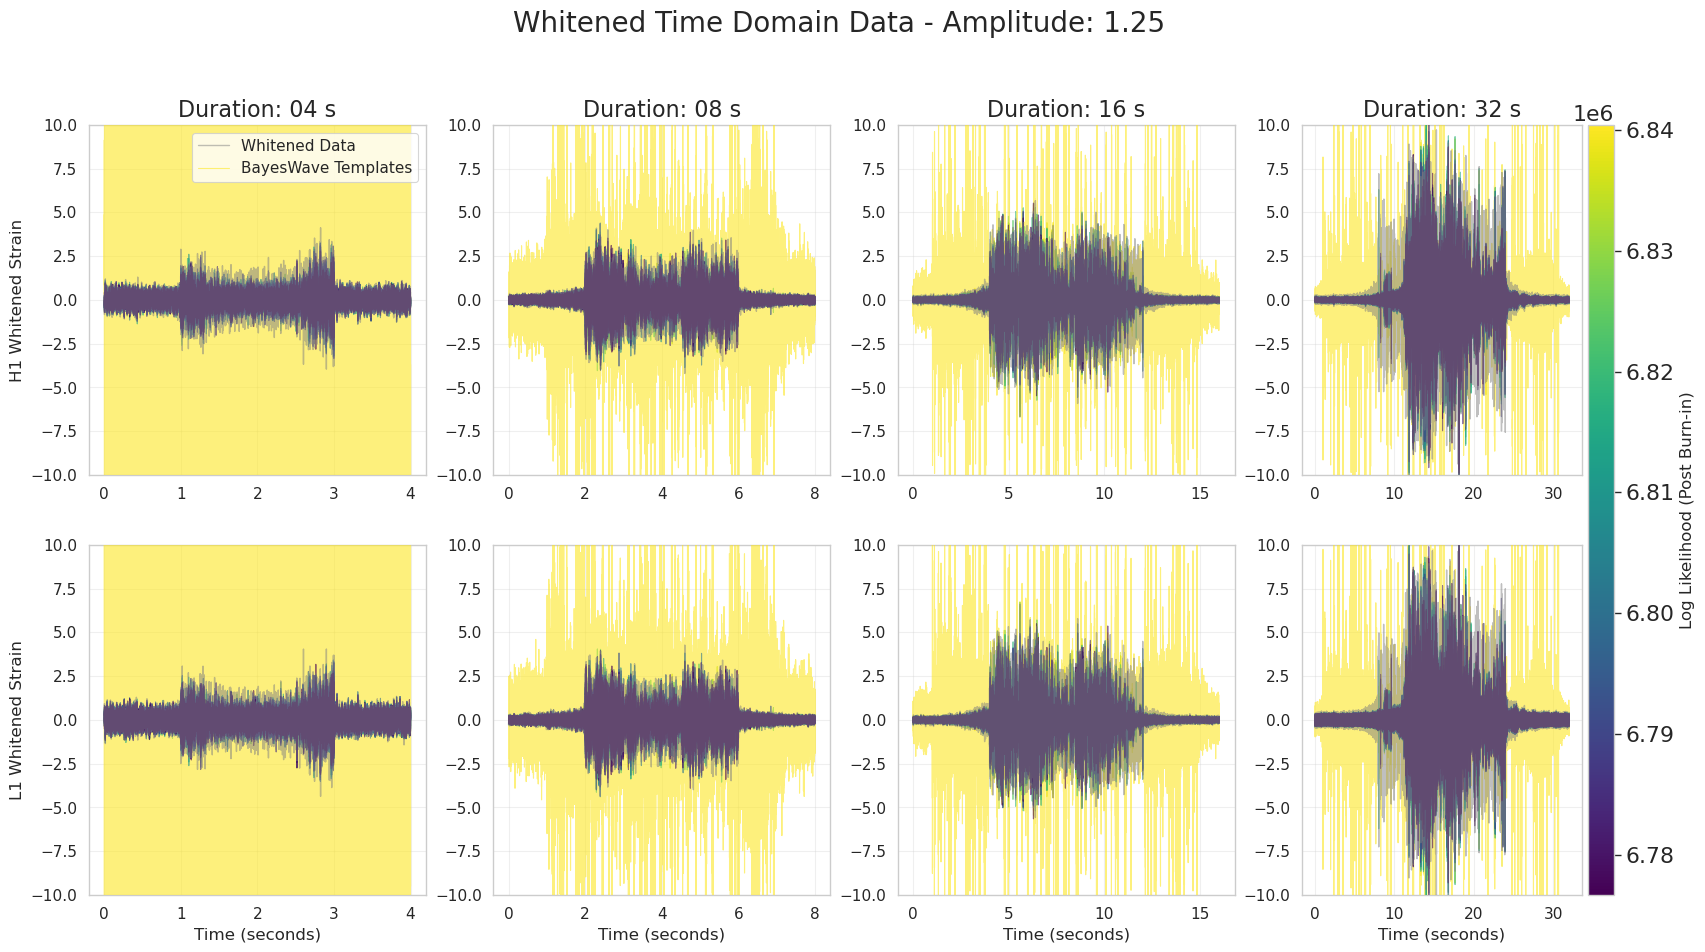

KeyboardInterrupt: 

In [5]:
# Plot whitened data: BayesWave reconstruction vs real strain
# Color templates by their likelihood values (using post-burn-in likelihoods)

burnin_frac = 0.6  # Burn-in fraction for likelihood chains
n_templates = 11   # Total number of templates (0-10)

for amp in amplitudes:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    for col_idx, dur in enumerate(durations):
        exp_dir = base_path / f'dur_{dur}_amp_{amp}'
        data_dir = exp_dir / 'bayeswave_output_0' / 'data'
        template_dir = exp_dir / 'bayeswave_output_0' / 'templates'
        chain_file = exp_dir / 'bayeswave_output_0' / 'chains' / 'all_chain_likelihoods.txt'
        
        # Load likelihood data with burn-in applied
        iterations, chains_full, iterations_pb, chains_pb = load_likelihood_chains(
            chain_file, burnin_frac=burnin_frac
        )
        
        # Get final (post-burn-in) likelihood value for each chain
        final_likelihoods = chains_pb[-1, :n_templates]  # Last iteration, chains 0-10
        
        # Create colormap normalization
        norm = Normalize(vmin=final_likelihoods.min(), vmax=final_likelihoods.max())
        cmap = plt.cm.viridis
        
        # Load whitened data
        h1_whitened = load_time_domain_data(data_dir / 'whitened_time_domain_data_H1.dat')
        l1_whitened = load_time_domain_data(data_dir / 'whitened_time_domain_data_L1.dat')
        
        # Plot H1
        ax_h1 = axes[0, col_idx]
        ax_h1.plot(h1_whitened[:, 0], h1_whitened[:, 1], '-', 
                   color='gray', linewidth=1, label='Whitened Data', alpha=0.5, zorder=10)
        
        # Plot all whitened BayesWave templates colored by post-burn-in likelihood
        for i in range(n_templates):
            template_file = template_dir / f'all_whitened_time_domain_template_H1_{i}.dat'
            if template_file.exists():
                h1_template = load_time_domain_data(template_file)
                
                # Color by post-burn-in likelihood
                color = cmap(norm(final_likelihoods[i]))
                label = 'BayesWave Templates' if i == 0 else None
                ax_h1.plot(h1_template[:, 0], h1_template[:, 1], '-', 
                           color=color, linewidth=0.8, label=label, alpha=0.6, zorder=5)
        
        ax_h1.set_title(f'Duration: {dur.replace("s", " s")}', fontsize=16)
        if col_idx == 0:
            ax_h1.set_ylabel('H1 Whitened Strain', fontsize=12)
            ax_h1.legend(loc='upper right', fontsize=11)
        ax_h1.grid(True, alpha=0.3)
        ax_h1.tick_params(axis='both', which='major', labelsize=11)
        ax_h1.set_ylim(-10, 10)
        
        # Plot L1
        ax_l1 = axes[1, col_idx]
        ax_l1.plot(l1_whitened[:, 0], l1_whitened[:, 1], '-', 
                   color='gray', linewidth=1, label='Whitened Data', alpha=0.5, zorder=10)
        
        # Plot all whitened BayesWave templates colored by post-burn-in likelihood
        for i in range(n_templates):
            template_file = template_dir / f'all_whitened_time_domain_template_L1_{i}.dat'
            if template_file.exists():
                l1_template = load_time_domain_data(template_file)
                
                # Color by post-burn-in likelihood
                color = cmap(norm(final_likelihoods[i]))
                label = 'BayesWave Templates' if i == 0 else None
                ax_l1.plot(l1_template[:, 0], l1_template[:, 1], '-', 
                           color=color, linewidth=0.8, label=label, alpha=0.6, zorder=5)
        
        if col_idx == 0:
            ax_l1.set_ylabel('L1 Whitened Strain', fontsize=12)
        ax_l1.set_xlabel('Time (seconds)', fontsize=12)
        ax_l1.grid(True, alpha=0.3)
        ax_l1.tick_params(axis='both', which='major', labelsize=11)
        ax_l1.set_ylim(-10, 10)
        
        # Add colorbar to the rightmost column
        if col_idx == len(durations) - 1:
            sm = ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            cbar = plt.colorbar(sm, ax=[axes[0, col_idx], axes[1, col_idx]], 
                               aspect=30, pad=0.02)
            cbar.set_label('Log Likelihood (Post Burn-in)', fontsize=12)
    
    fig.suptitle(f'Whitened Time Domain Data - Amplitude: {amp}', fontsize=20, y=0.995)
    plt.show()

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x151e29539520>>
Traceback (most recent call last):
  File "/home/x-ctirapongpra/.conda/envs/2024.02-py311/bayeswave-cpp/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


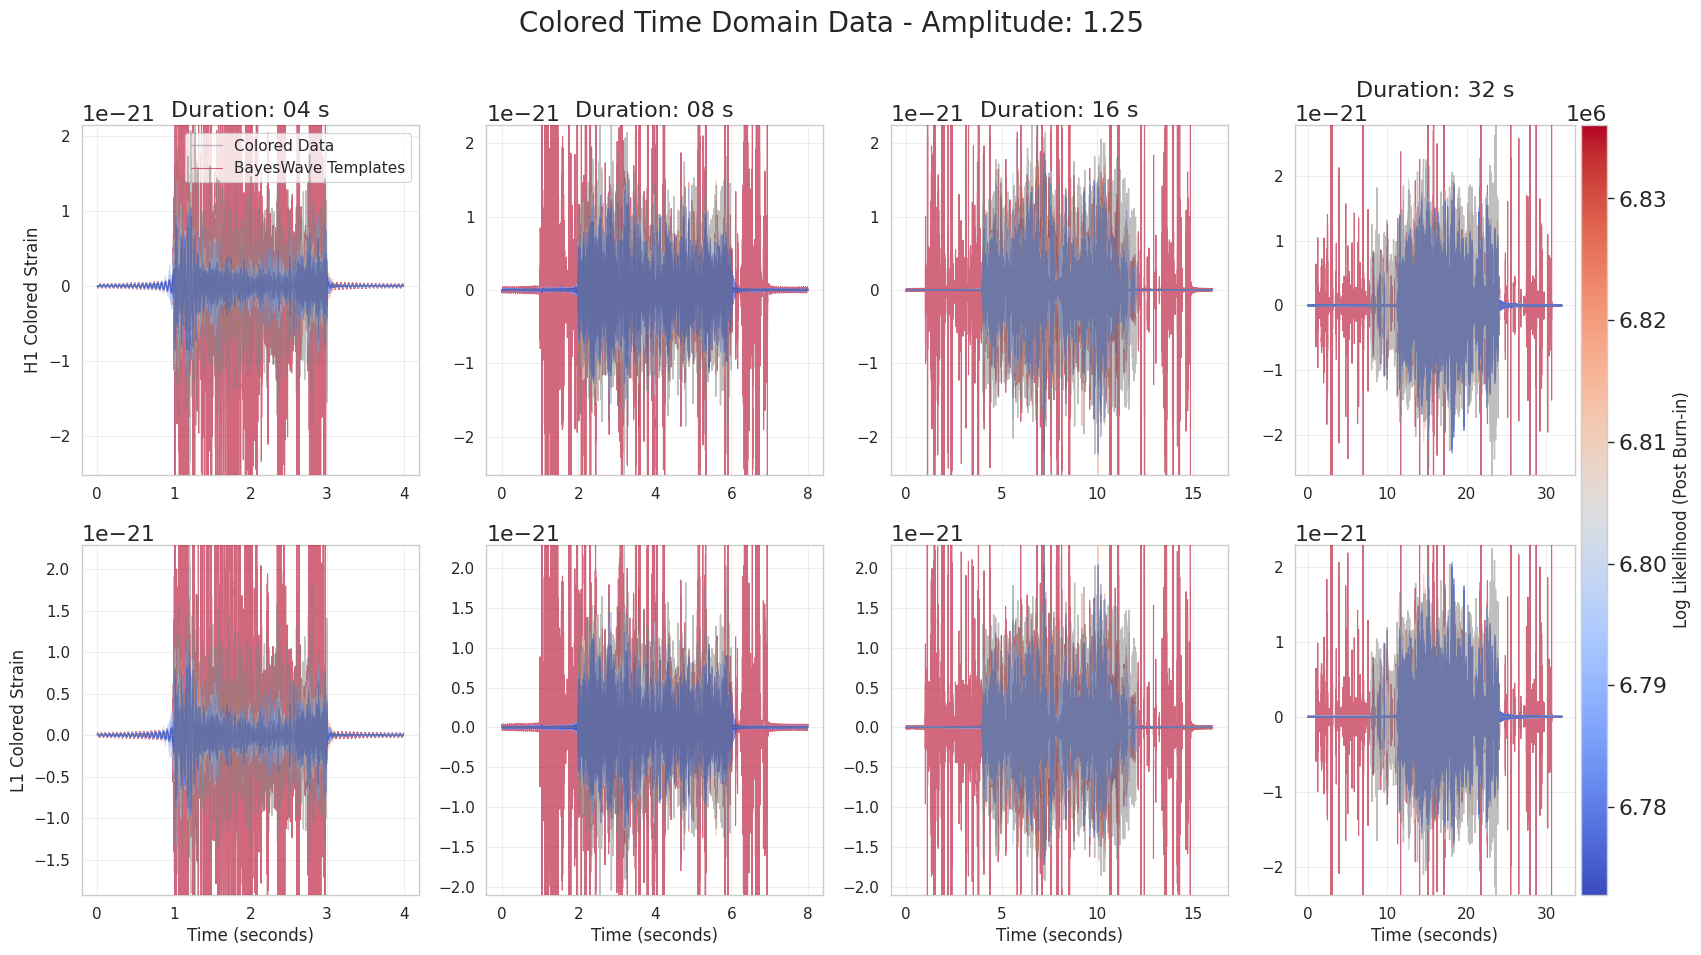

In [ ]:
# Plot colored data: BayesWave reconstruction vs real strain
# Color templates by their likelihood values (using post-burn-in likelihoods)

burnin_frac = 0.6  # Burn-in fraction for likelihood chains
n_templates = 11   # Total number of templates (0-10)

for amp in amplitudes:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    for col_idx, dur in enumerate(durations):
        exp_dir = base_path / f'dur_{dur}_amp_{amp}'
        data_dir = exp_dir / 'bayeswave_output_0' / 'data'
        template_dir = exp_dir / 'bayeswave_output_0' / 'templates'
        chain_file = exp_dir / 'bayeswave_output_0' / 'chains' / 'all_chain_likelihoods.txt'
        
        # Load likelihood data with burn-in applied
        iterations, chains_full, iterations_pb, chains_pb = load_likelihood_chains(
            chain_file, burnin_frac=burnin_frac
        )
        
        # Get final (post-burn-in) likelihood value for each chain
        final_likelihoods = chains_pb[-1, :n_templates]  # Last iteration, chains 0-10
        
        # Create colormap normalization
        norm = Normalize(vmin=final_likelihoods.min(), vmax=final_likelihoods.max())
        cmap = plt.cm.coolwarm
        
        # Load colored data
        h1_colored = load_time_domain_data(data_dir / 'colored_time_domain_data_H1.dat')
        l1_colored = load_time_domain_data(data_dir / 'colored_time_domain_data_L1.dat')
        
        # Plot H1
        ax_h1 = axes[0, col_idx]
        ax_h1.plot(h1_colored[:, 0], h1_colored[:, 1], '-', 
                   color='gray', linewidth=1, label='Colored Data', alpha=0.5, zorder=10)

        
        # Plot all colored BayesWave templates colored by post-burn-in likelihood
        for i in range(n_templates):
            template_file = template_dir / f'all_colored_time_domain_template_H1_{i}.dat'
            if template_file.exists():
                h1_template = load_time_domain_data(template_file)
                
                # Color by post-burn-in likelihood
                color = cmap(norm(final_likelihoods[i]))
                label = 'BayesWave Templates' if i == 0 else None
                ax_h1.plot(h1_template[:, 0], h1_template[:, 1], '-', 
                           color=color, linewidth=0.8, label=label, alpha=0.6, zorder=5)
        
        ax_h1.set_title(f'Duration: {dur.replace("s", " s")}', fontsize=16)
        if col_idx == 0:
            ax_h1.set_ylabel('H1 Colored Strain', fontsize=12)
            ax_h1.legend(loc='upper right', fontsize=11)
        ax_h1.grid(True, alpha=0.3)
        ax_h1.tick_params(axis='both', which='major', labelsize=11)
        ax_h1.set_ylim(h1_colored[:, 1].min()*(1.0+1e-20), h1_colored[:, 1].max()*(1.0+1e-20))
        
        # Plot L1
        ax_l1 = axes[1, col_idx]
        ax_l1.plot(l1_colored[:, 0], l1_colored[:, 1], '-', 
                   color='gray', linewidth=1, label='Colored Data', alpha=0.5, zorder=10)
        
        # Plot all colored BayesWave templates colored by post-burn-in likelihood
        for i in range(n_templates):
            template_file = template_dir / f'all_colored_time_domain_template_L1_{i}.dat'
            if template_file.exists():
                l1_template = load_time_domain_data(template_file)
                
                # Color by post-burn-in likelihood
                color = cmap(norm(final_likelihoods[i]))
                label = 'BayesWave Templates' if i == 0 else None
                ax_l1.plot(l1_template[:, 0], l1_template[:, 1], '-', 
                           color=color, linewidth=0.8, label=label, alpha=0.6, zorder=5)
        
        if col_idx == 0:
            ax_l1.set_ylabel('L1 Colored Strain', fontsize=12)
        ax_l1.set_xlabel('Time (seconds)', fontsize=12)
        ax_l1.grid(True, alpha=0.3)
        ax_l1.tick_params(axis='both', which='major', labelsize=11)
        ax_l1.set_ylim(l1_colored[:, 1].min()*(1.0+1e-20), l1_colored[:, 1].max()*(1.0+1e-20))
        
        # Add colorbar to the rightmost column
        if col_idx == len(durations) - 1:
            sm = ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            cbar = plt.colorbar(sm, ax=[axes[0, col_idx], axes[1, col_idx]], 
                               aspect=30, pad=0.02)
            cbar.set_label('Log Likelihood (Post Burn-in)', fontsize=12)
    
    fig.suptitle(f'Colored Time Domain Data - Amplitude: {amp}', fontsize=20, y=0.995)
    plt.show()

Check if the MCMC chains have converged by examining:
1. **Trace plots**: Log-likelihood vs iteration
2. **Likelihood distributions**: Histograms showing all chains sample the same distribution

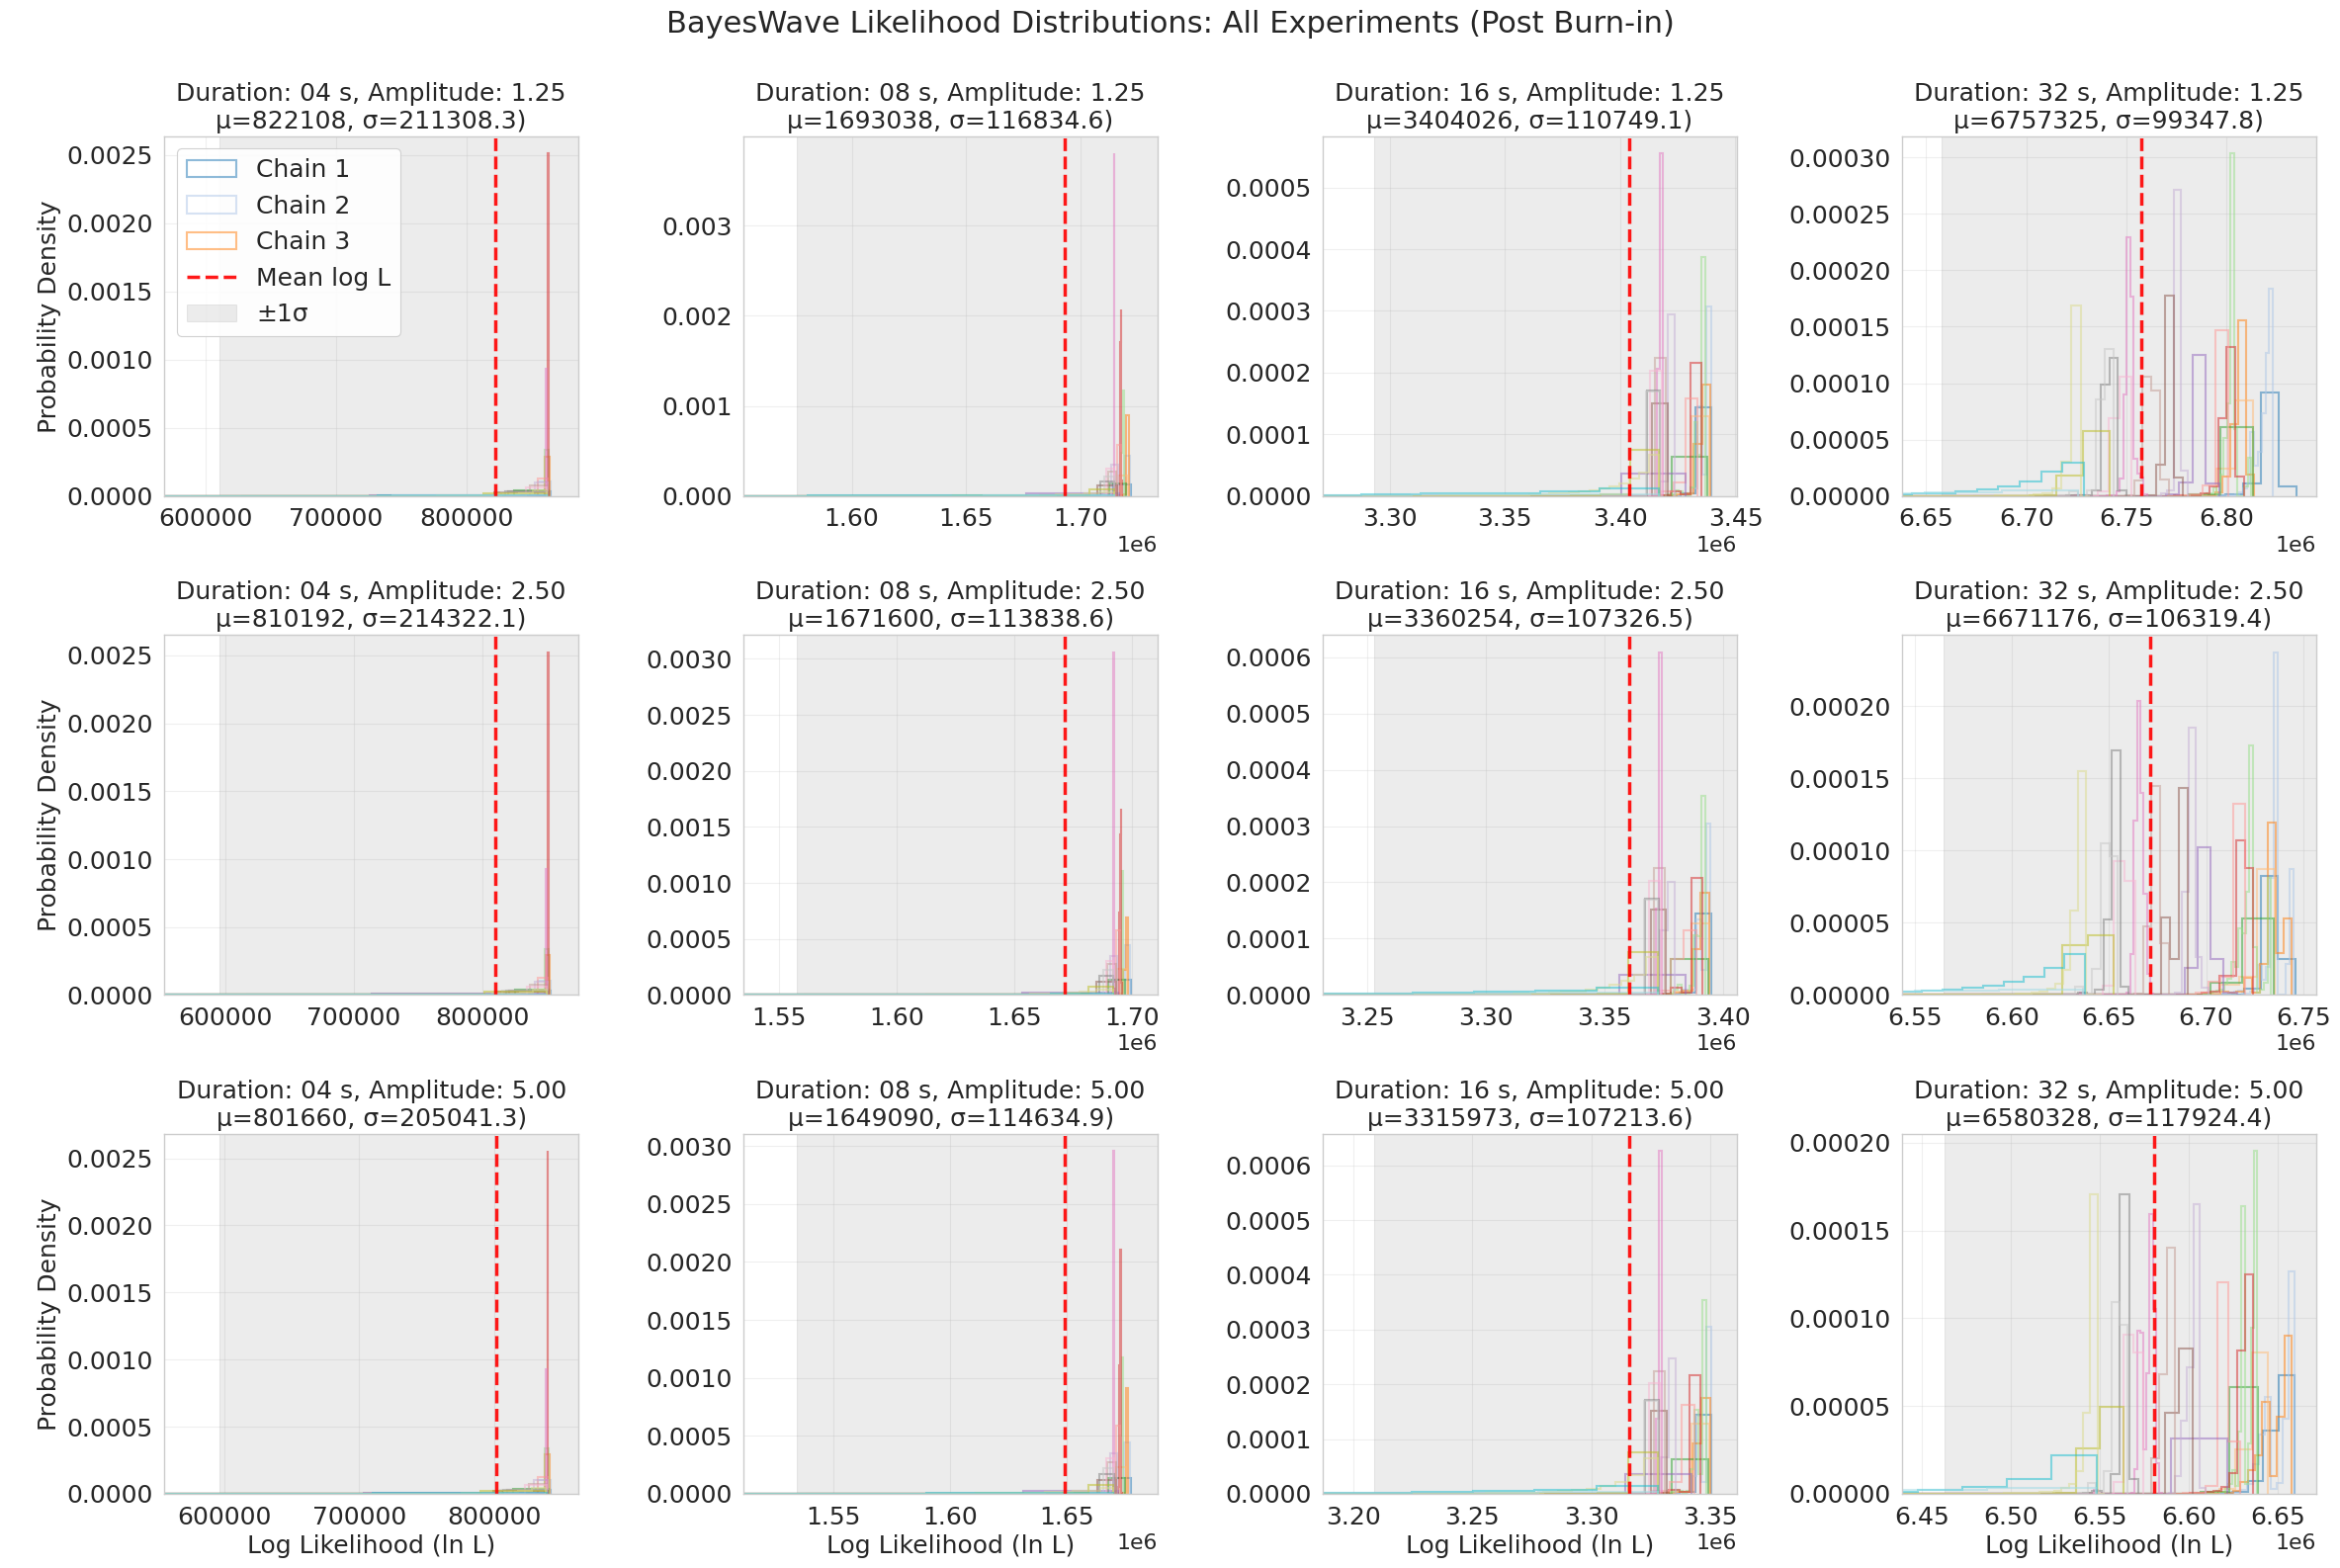

In [ ]:
# Comprehensive comparison across all experiments
# Each colored line = 1 chain (20 total)
fig, axes = plt.subplots(len(amplitudes), len(durations), figsize=(24, 16))

for row_idx, amp in enumerate(amplitudes):
    for col_idx, dur in enumerate(durations):
        exp_dir = base_path / f'dur_{dur}_amp_{amp}'
        chain_file = exp_dir / 'bayeswave_output_0' / 'chains' / 'all_chain_likelihoods.txt'
        
        if not chain_file.exists():
            axes[row_idx, col_idx].text(0.5, 0.5, 'No data', 
                                        ha='center', va='center', fontsize=18)
            axes[row_idx, col_idx].set_title(f'dur={dur}, amp={amp}', fontsize=14)
            continue
        
        # Load chains
        iterations, chains_full, iterations_pb, chains_pb = load_likelihood_chains(
            chain_file, burnin_frac=0.1
        )
        
        ax = axes[row_idx, col_idx]
        
        n_chains = chains_pb.shape[1]
        
        # Plot individual chain histograms as step plots
        colors = plt.cm.tab20(np.linspace(0, 1, n_chains))
        for i in range(n_chains):
            label = f'Chain {i+1}' if row_idx == 0 and col_idx == 0 and i < 3 else None
            ax.hist(chains_pb[:, i], bins=80, alpha=0.5, color=colors[i], 
                    density=True, histtype='step', linewidth=1.5, label=label)
        
        # Add statistics
        mean_logL = chains_pb.mean()
        std_logL = chains_pb.std()
        ax.axvline(mean_logL, color='red', linestyle='--', linewidth=2.5, alpha=0.9, label='Mean log L')
        
        # Add shaded region for ±1 std
        ax.axvspan(mean_logL - std_logL, mean_logL + std_logL, 
                   alpha=0.15, color='gray', label='±1σ')
        
        # Zoom in on the data range
        ax.set_xlim(mean_logL - 1.2*std_logL, chains_pb.max()+0.1*std_logL)
        
        ax.set_title(f'Duration: {dur.replace("s", " s")}, Amplitude: {amp}\nμ={mean_logL:.0f}, σ={std_logL:.1f})', 
                     fontsize=18)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', which='major', labelsize=18)
        
        # Add legend only to the first subplot
        if row_idx == 0 and col_idx == 0:
            ax.legend(loc='upper left', fontsize=18, framealpha=0.9)
        
        if col_idx == 0:
            ax.set_ylabel(f'\nProbability Density', fontsize=18)
        if row_idx == len(amplitudes) - 1:
            ax.set_xlabel('Log Likelihood (ln L)', fontsize=18)

fig.suptitle('BayesWave Likelihood Distributions: All Experiments (Post Burn-in)', 
             fontsize=22, y=0.995)
plt.tight_layout()
plt.show()

In [ ]:
def gelman_rubin(chains):
    """Calculate Gelman-Rubin convergence diagnostic (R-hat).
    
    Parameters
    ----------
    chains : np.ndarray
        Array with shape (n_iterations, n_chains)
    
    Returns
    -------
    float
        R-hat statistic. Values close to 1.0 indicate convergence.
        Typically, R-hat < 1.1 is considered acceptable.
    """
    n_iterations, n_chains = chains.shape
    
    # Calculate within-chain variance (W)
    chain_variances = np.var(chains, axis=0, ddof=1)
    W = np.mean(chain_variances)
    
    # Calculate between-chain variance (B)
    chain_means = np.mean(chains, axis=0)
    overall_mean = np.mean(chain_means)
    B = n_iterations * np.var(chain_means, ddof=1)
    
    # Estimate of marginal posterior variance
    var_plus = ((n_iterations - 1) / n_iterations) * W + (1 / n_iterations) * B
    
    # R-hat statistic
    R_hat = np.sqrt(var_plus / W)
    
    return R_hat

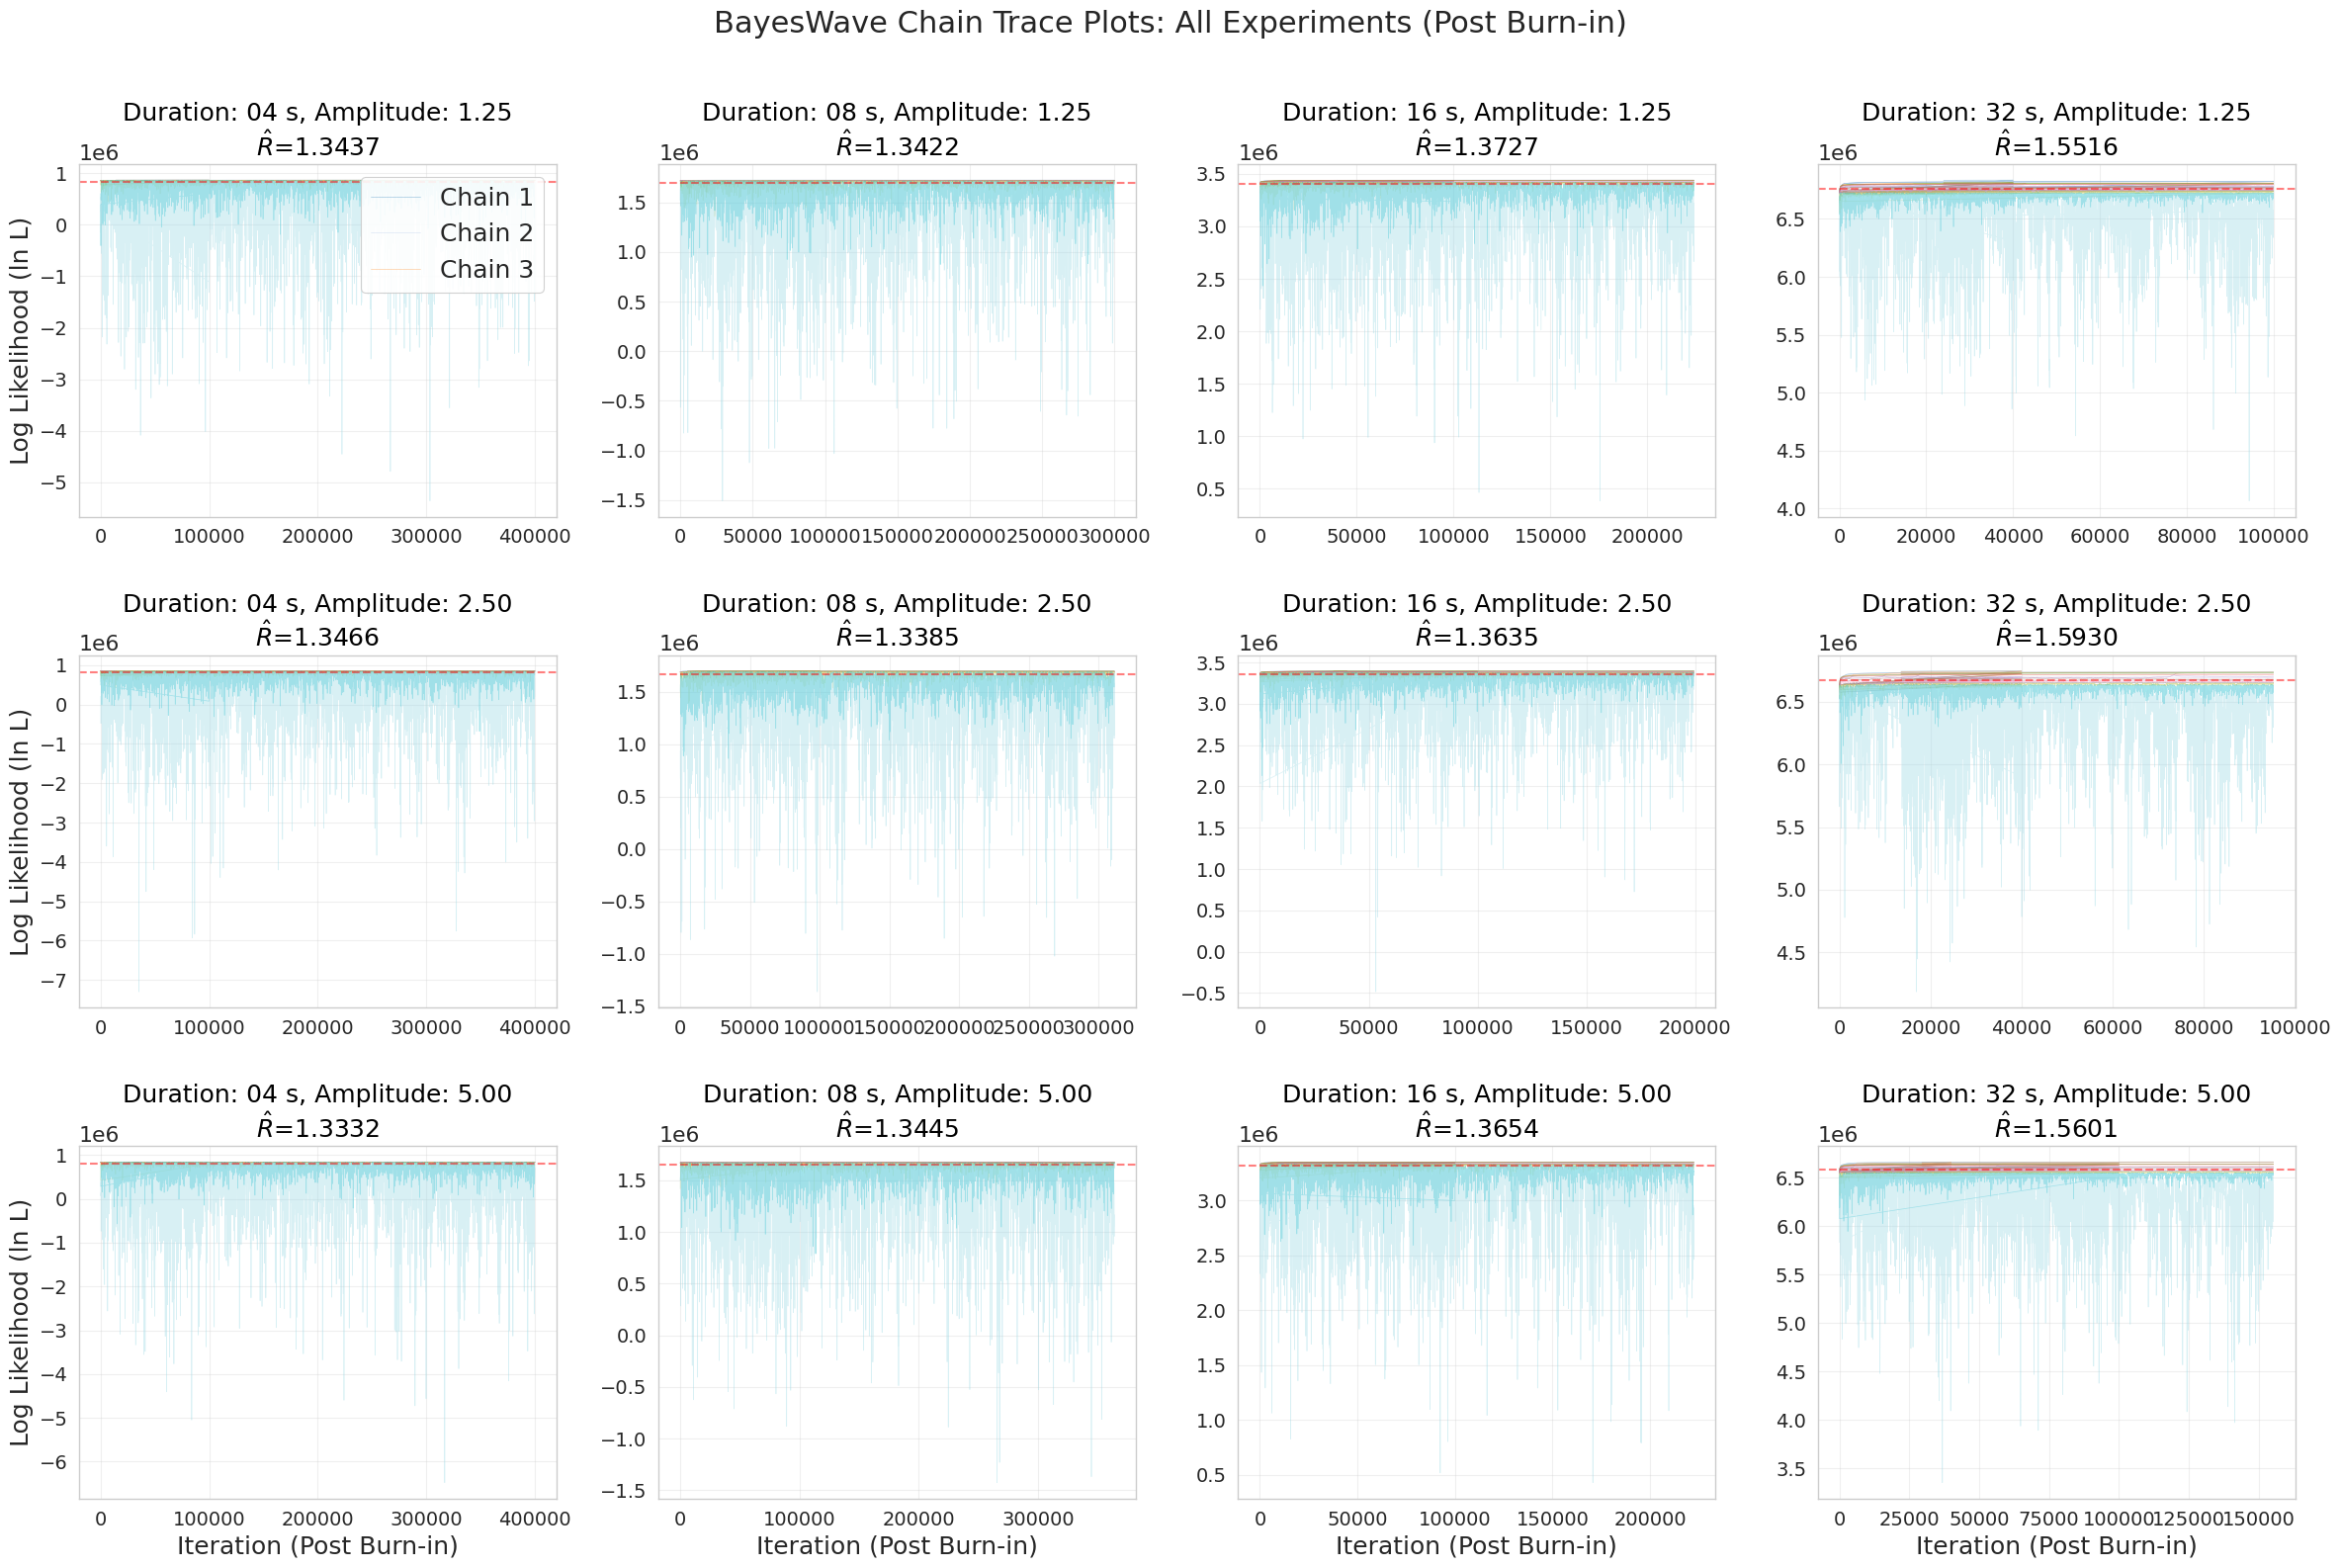

In [ ]:
# Trace plots for all experiments (post burn-in only)
fig, axes = plt.subplots(len(amplitudes), len(durations), figsize=(24, 16))

for row_idx, amp in enumerate(amplitudes):
    for col_idx, dur in enumerate(durations):
        exp_dir = base_path / f'dur_{dur}_amp_{amp}'
        chain_file = exp_dir / 'bayeswave_output_0' / 'chains' / 'all_chain_likelihoods.txt'
        
        ax = axes[row_idx, col_idx]
        
        if not chain_file.exists():
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=18)
            ax.set_title(f'Duration: {dur.replace("s", " s")}, Amplitude: {amp}', fontsize=14)
            continue
        
        # Load chains
        iterations, chains_full, iterations_pb, chains_pb = load_likelihood_chains(
            chain_file, burnin_frac=0.1
        )
        
        # Plot post burn-in chains (downsample for visibility)
        n_chains = chains_pb.shape[1]
        downsample = max(1, len(iterations_pb) // 5000)  # Limit to ~5000 points per chain
        
        colors = plt.cm.tab20(np.linspace(0, 1, n_chains))
        for i in range(n_chains):
            label = f'Chain {i+1}' if row_idx == 0 and col_idx == 0 and i < 3 else None
            ax.plot(iterations_pb[::downsample], chains_pb[::downsample, i], 
                   alpha=0.4, linewidth=0.5, color=colors[i], label=label)
        
        # Calculate R-hat for title
        R_hat = gelman_rubin(chains_pb)
        
        # Color-code R-hat based on convergence threshold
        rhat_color = 'green' if R_hat < 1.1 else 'orange' if R_hat < 1.2 else 'red'
        
        ax.set_title(f'Duration: {dur.replace("s", " s")}, Amplitude: {amp}\n' + 
                     r'$\hat{R}$' + f'={R_hat:.4f}', 
                     fontsize=18, color='black')
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', which='major', labelsize=14)
        
        # Add legend only to the first subplot
        if row_idx == 0 and col_idx == 0:
            ax.legend(loc='upper right', fontsize=18, framealpha=0.9)
        
        # Add horizontal line at mean for reference
        mean_logL = chains_pb.mean()
        ax.axhline(mean_logL, color='red', linestyle='--', linewidth=1.5, alpha=0.5)
        
        if col_idx == 0:
            ax.set_ylabel(f'Log Likelihood (ln L)', fontsize=18)
        if row_idx == len(amplitudes) - 1:
            ax.set_xlabel('Iteration (Post Burn-in)', fontsize=18)

fig.suptitle('BayesWave Chain Trace Plots: All Experiments (Post Burn-in)', 
             fontsize=22, y=0.995)
plt.tight_layout()
plt.show()

## Residual Analysis

Analyze the residuals (data - template) to check if BayesWave has properly subtracted the signal.

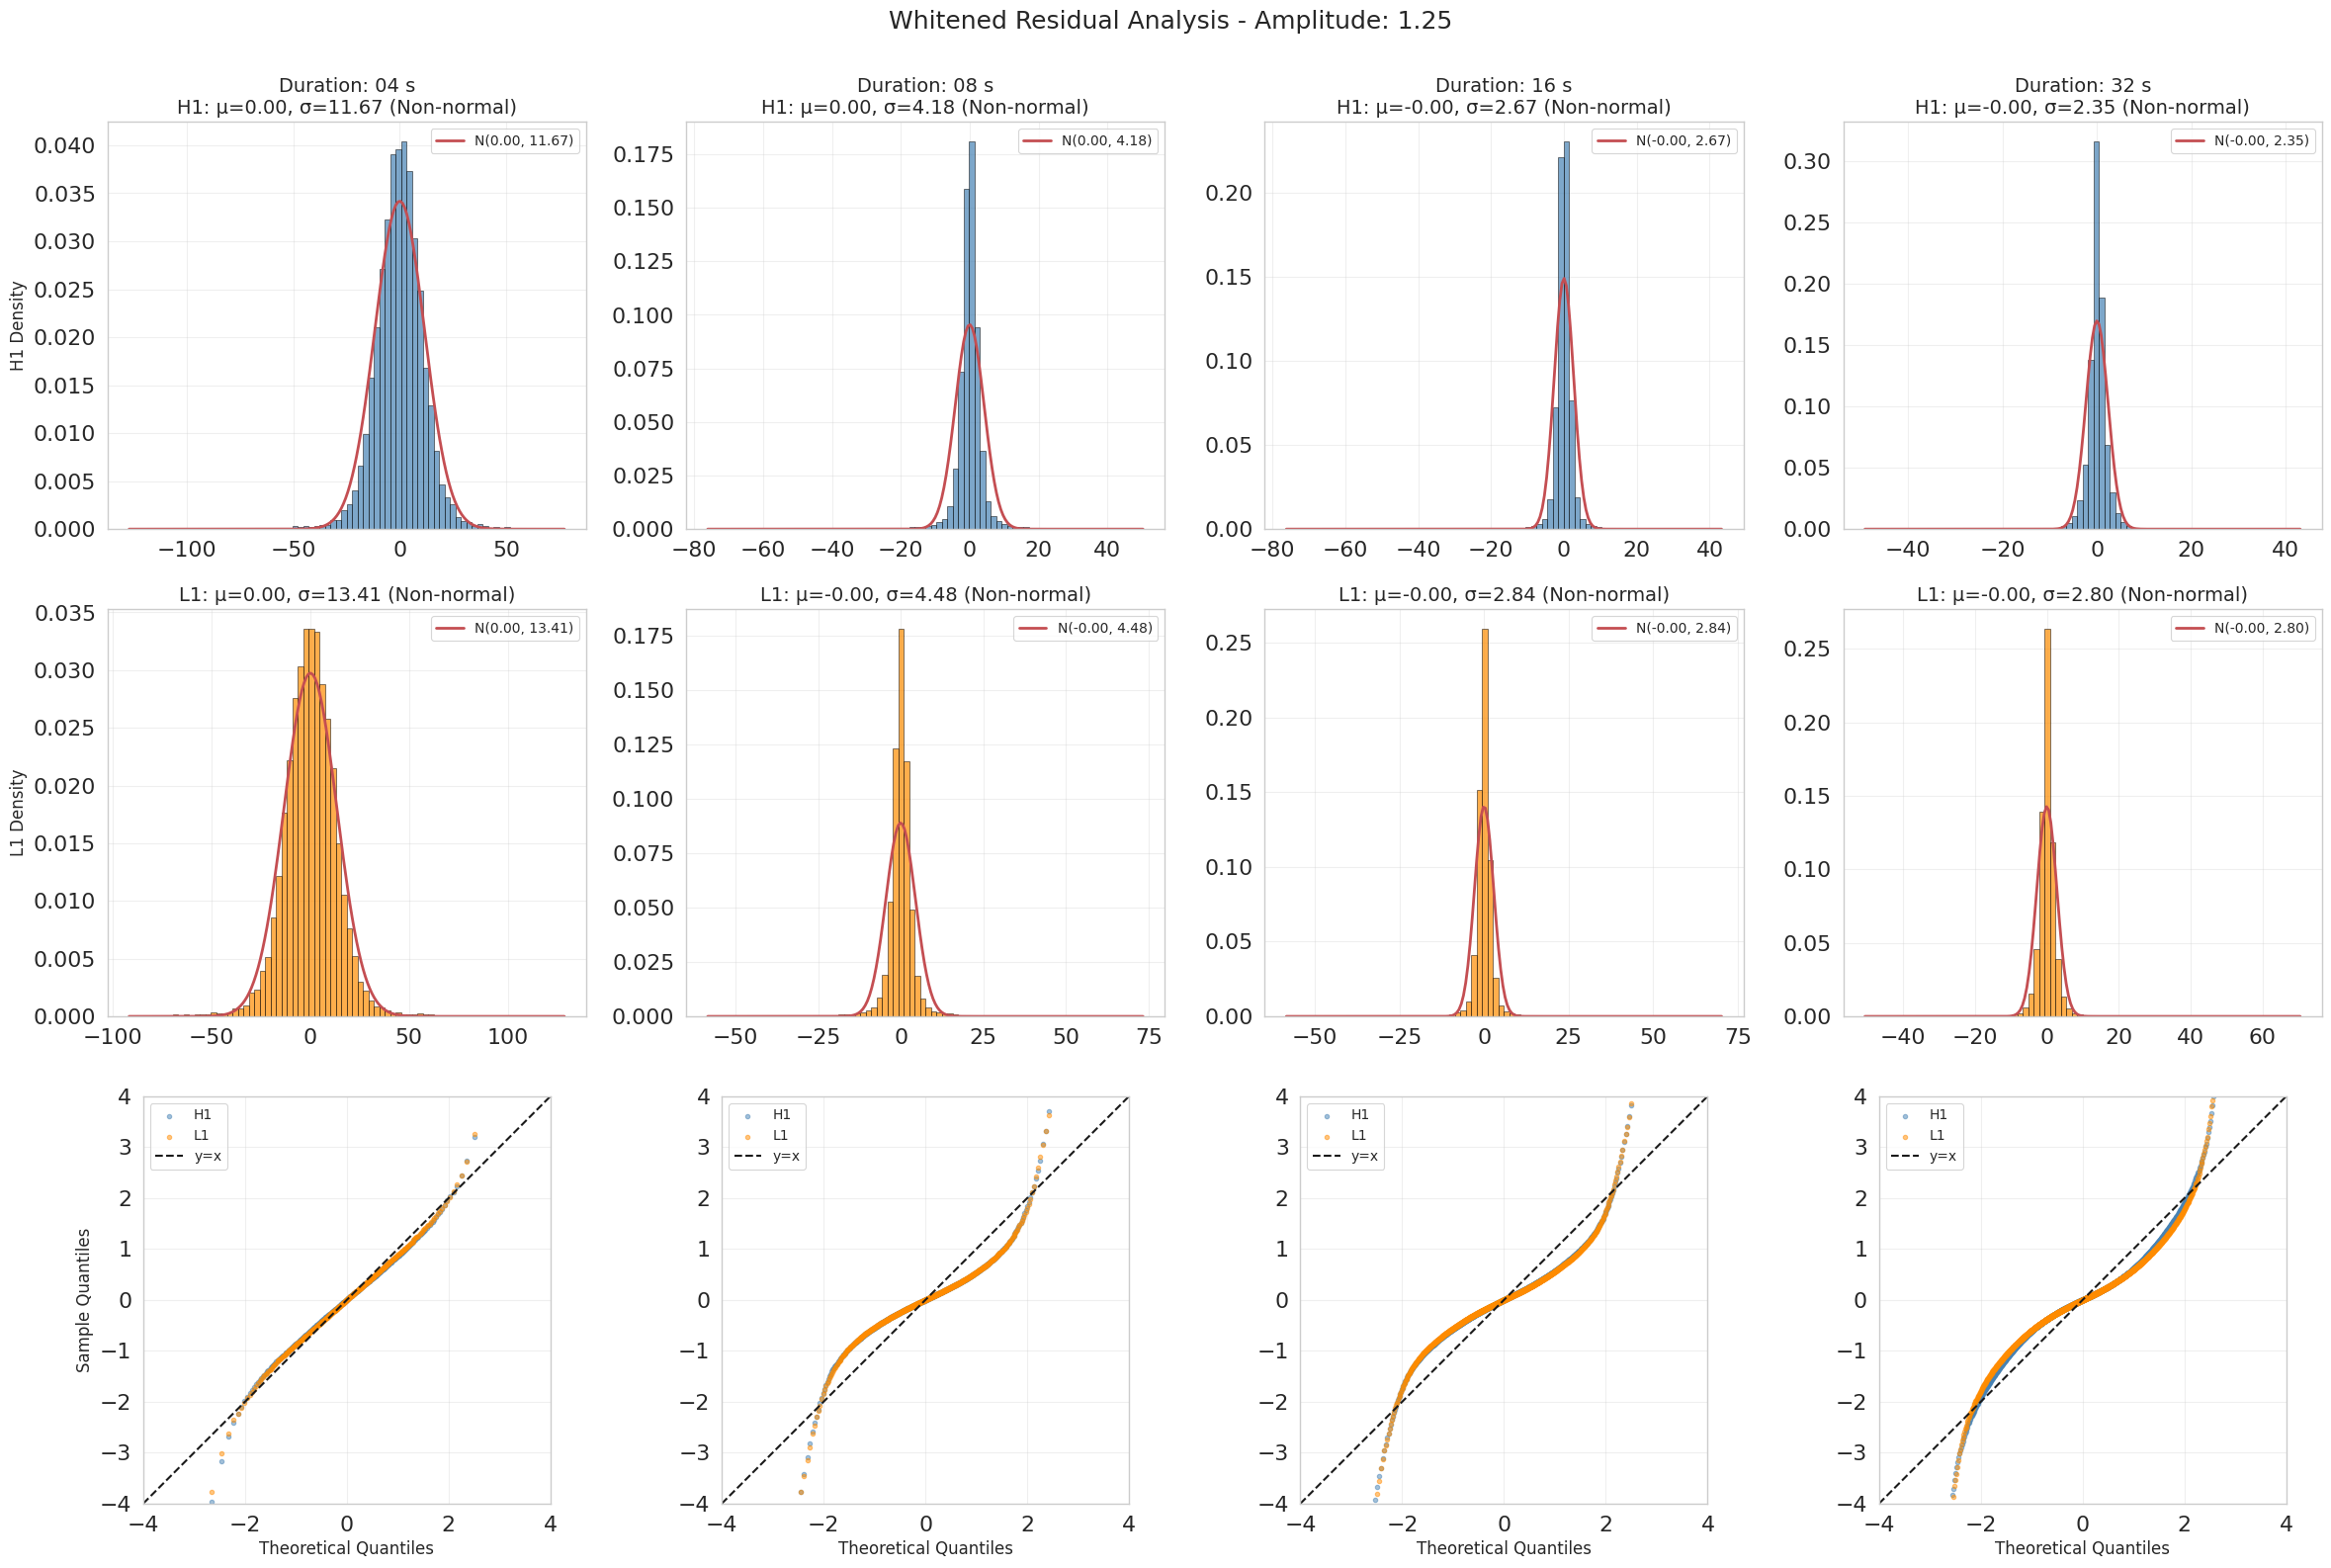

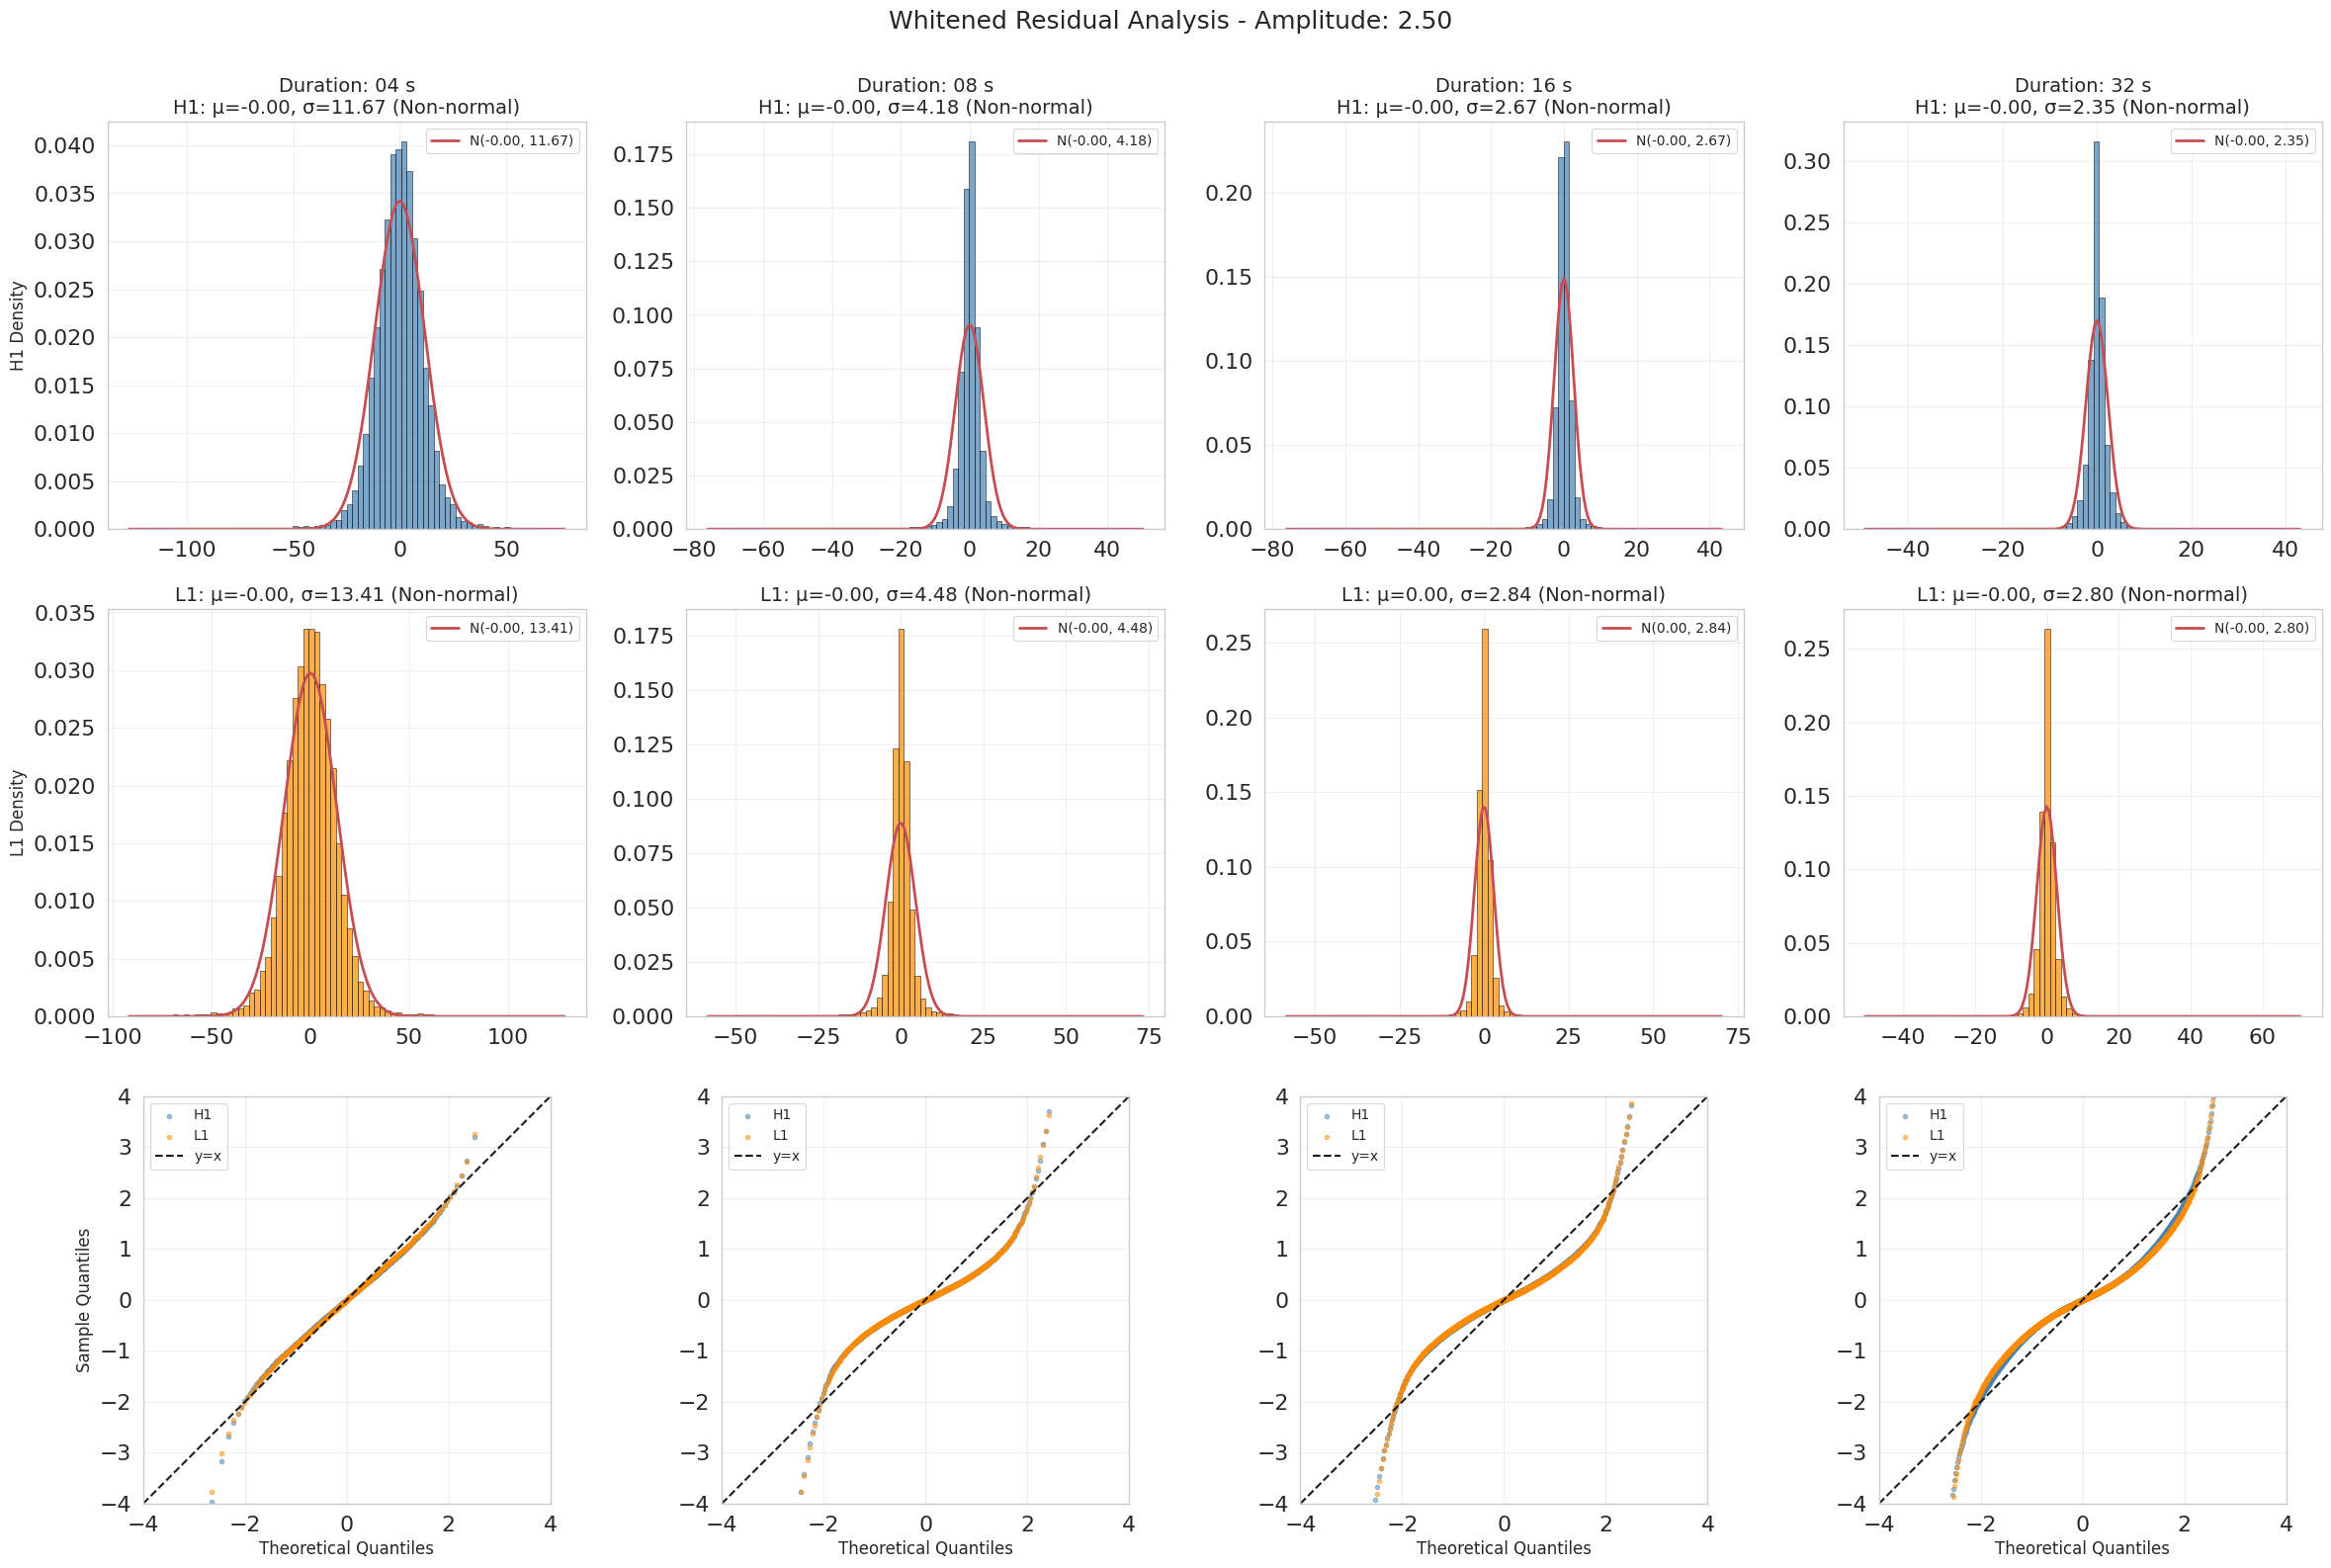

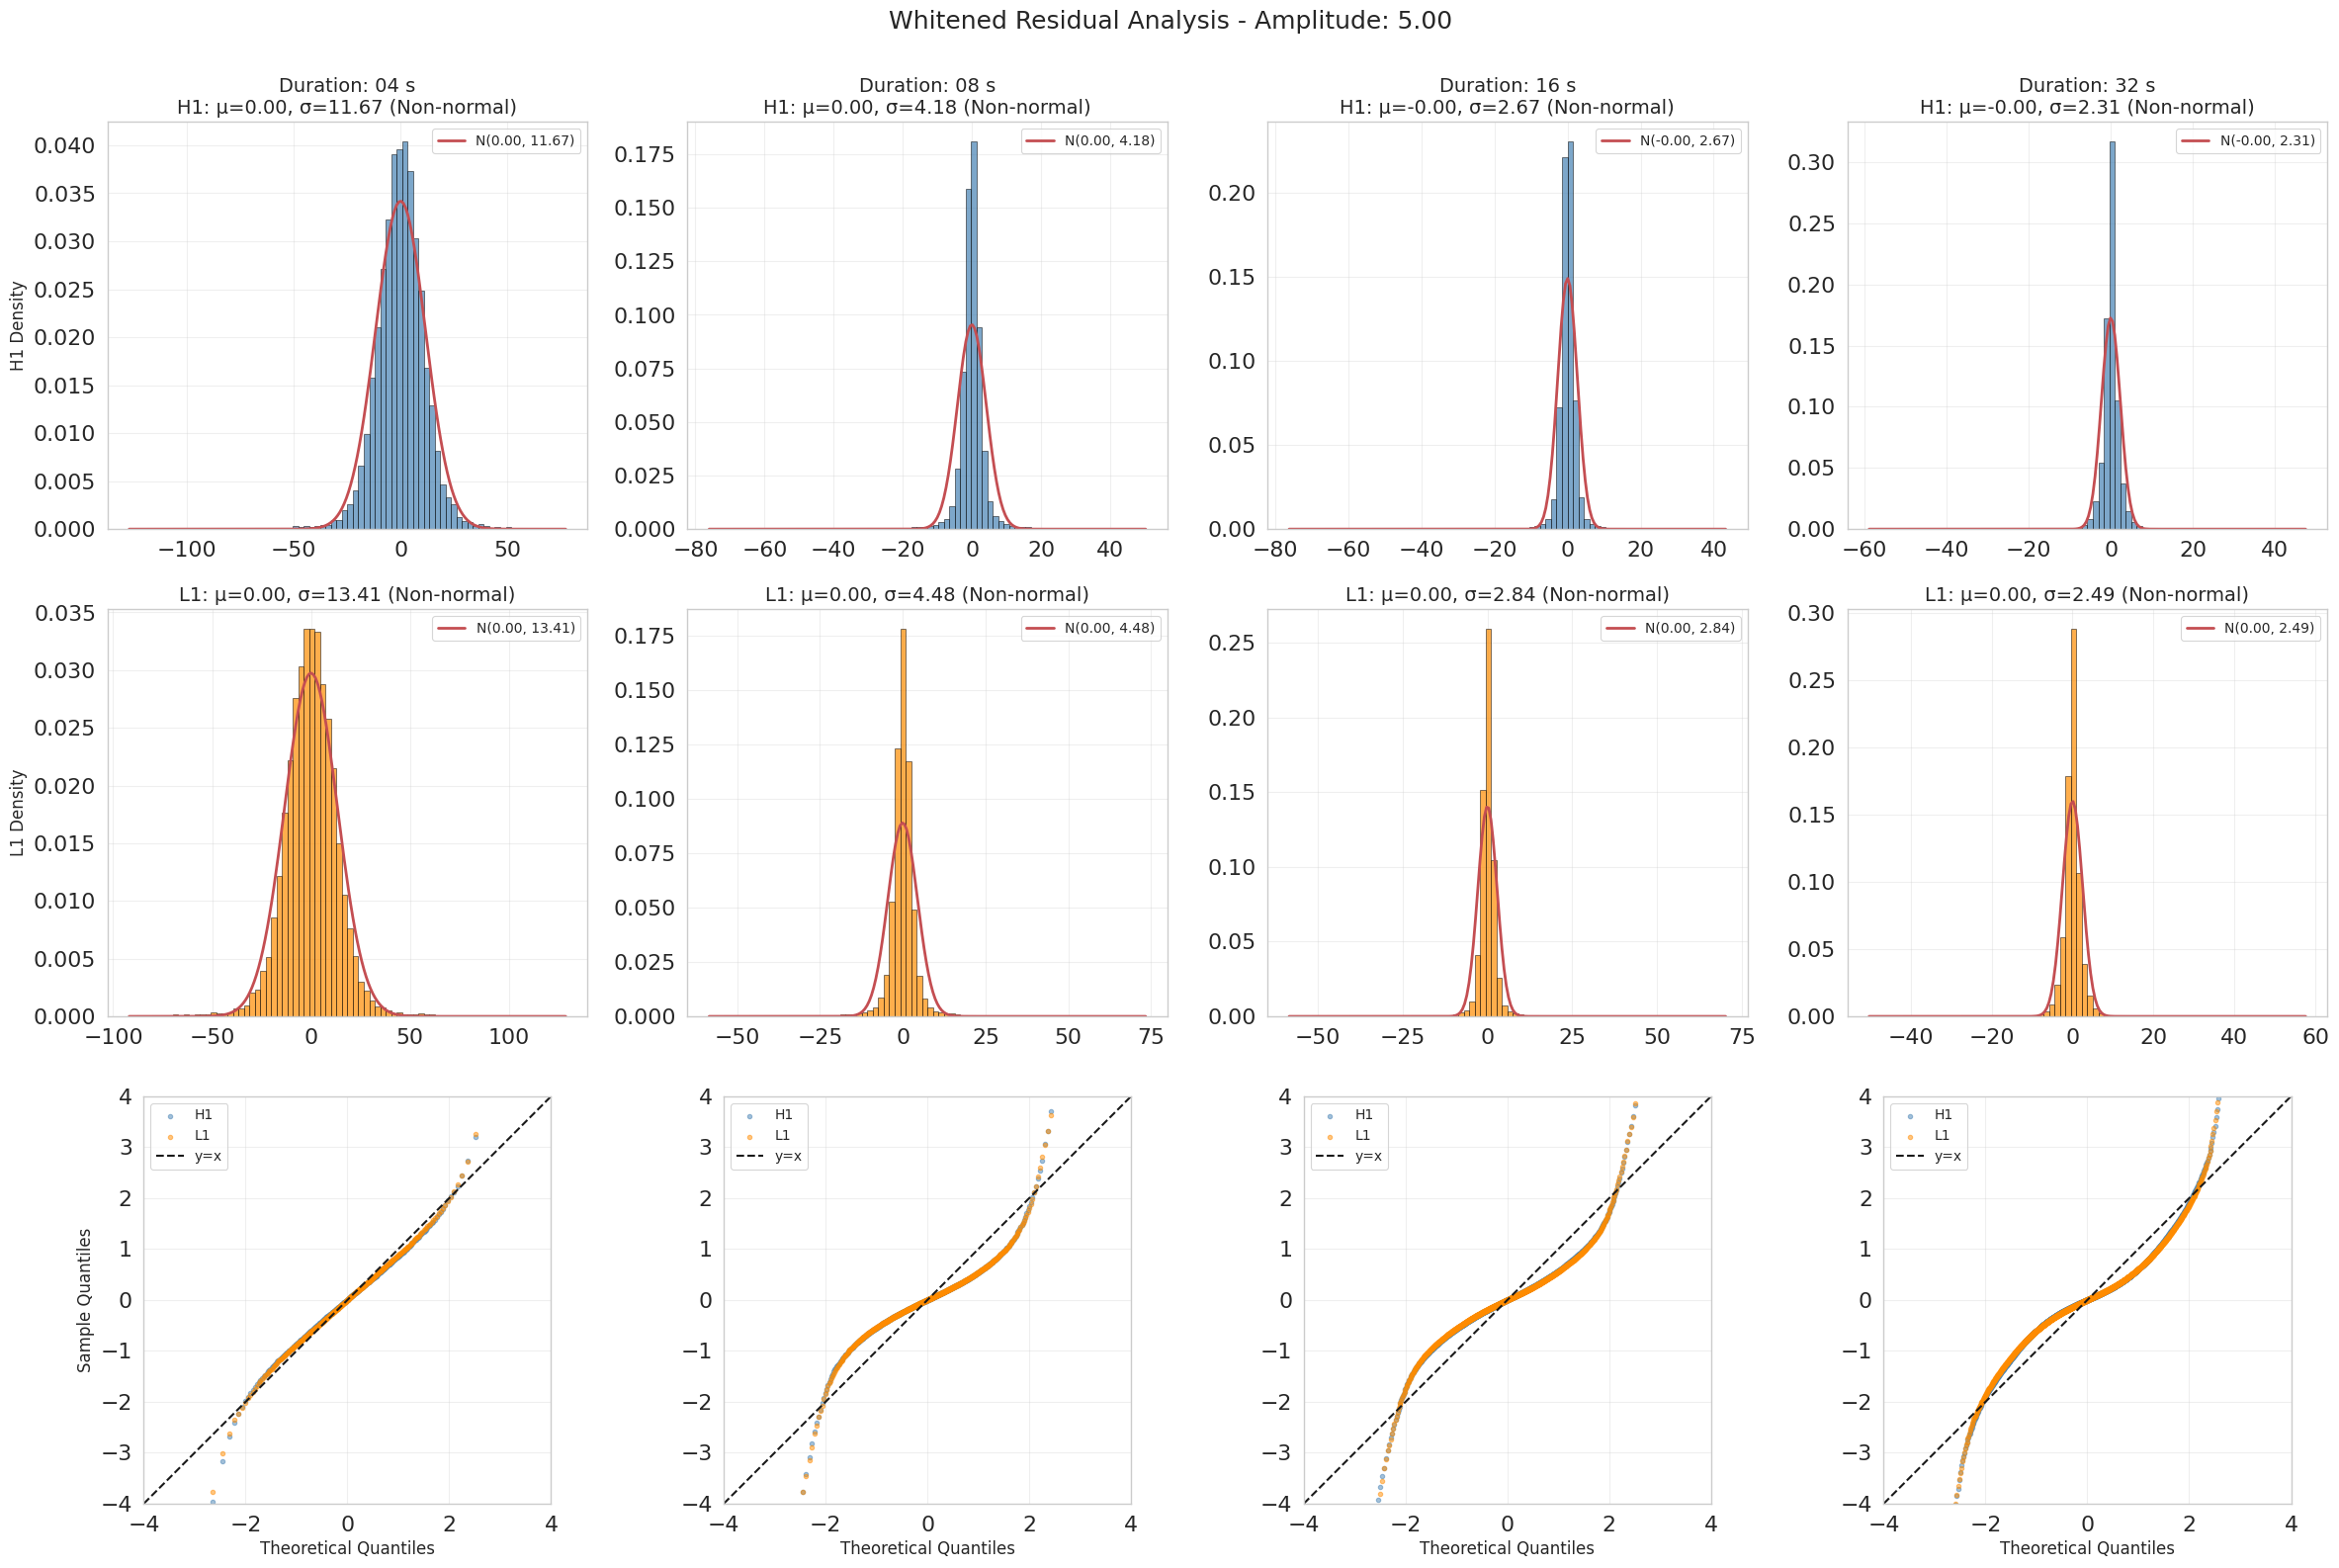

In [ ]:
from scipy import stats

# Residual Analysis: Histograms with Gaussian fit and Q-Q plots
for amp in amplitudes:
    fig, axes = plt.subplots(3, len(durations), figsize=(24, 16))
    
    for col_idx, dur in enumerate(durations):
        exp_dir = base_path / f'dur_{dur}_amp_{amp}'
        template_dir = exp_dir / 'bayeswave_output_0' / 'templates'
        
        # Load whitened residuals from chain 0 (best fit)
        h1_residual_file = template_dir / 'whitened_time_domain_residual_H1_0.dat'
        l1_residual_file = template_dir / 'whitened_time_domain_residual_L1_0.dat'
        
        if not h1_residual_file.exists():
            for row in range(3):
                axes[row, col_idx].text(0.5, 0.5, 'No data', ha='center', va='center')
            continue
        
        h1_residual = load_time_domain_data(h1_residual_file)
        l1_residual = load_time_domain_data(l1_residual_file)
        
        # Row 0: H1 residual histogram
        ax_h1 = axes[0, col_idx]
        h1_vals = h1_residual[:, 1]
        
        # Plot histogram
        n, bins, _ = ax_h1.hist(h1_vals, bins=80, density=True, alpha=0.7, 
                                 color='steelblue', edgecolor='black', linewidth=0.5)
        
        # Overlay Gaussian fit
        mu, std = h1_vals.mean(), h1_vals.std()
        x_fit = np.linspace(bins[0], bins[-1], 200)
        gaussian = stats.norm.pdf(x_fit, mu, std)
        ax_h1.plot(x_fit, gaussian, 'r-', linewidth=2, label=f'N({mu:.2f}, {std:.2f})')
        
        # Anderson-Darling test for normality
        stat, crit, sig = stats.anderson(h1_vals, dist='norm')
        p_text = 'Normal' if stat < crit[2] else 'Non-normal'
        
        ax_h1.set_title(f'Duration: {dur.replace("s", " s")}\nH1: μ={mu:.2f}, σ={std:.2f} ({p_text})', fontsize=14)
        ax_h1.legend(fontsize=10)
        ax_h1.grid(True, alpha=0.3)
        if col_idx == 0:
            ax_h1.set_ylabel('H1 Density', fontsize=12)
        
        # Row 1: L1 residual histogram
        ax_l1 = axes[1, col_idx]
        l1_vals = l1_residual[:, 1]
        
        n, bins, _ = ax_l1.hist(l1_vals, bins=80, density=True, alpha=0.7, 
                                 color='darkorange', edgecolor='black', linewidth=0.5)
        
        mu, std = l1_vals.mean(), l1_vals.std()
        x_fit = np.linspace(bins[0], bins[-1], 200)
        gaussian = stats.norm.pdf(x_fit, mu, std)
        ax_l1.plot(x_fit, gaussian, 'r-', linewidth=2, label=f'N({mu:.2f}, {std:.2f})')
        
        stat, crit, sig = stats.anderson(l1_vals, dist='norm')
        p_text = 'Normal' if stat < crit[2] else 'Non-normal'
        
        ax_l1.set_title(f'L1: μ={mu:.2f}, σ={std:.2f} ({p_text})', fontsize=14)
        ax_l1.legend(fontsize=10)
        ax_l1.grid(True, alpha=0.3)
        if col_idx == 0:
            ax_l1.set_ylabel('L1 Density', fontsize=12)
        
        # Row 2: Q-Q plots (both detectors)
        ax_qq = axes[2, col_idx]
        
        # H1 Q-Q plot
        h1_sorted = np.sort(h1_vals)
        h1_theoretical = stats.norm.ppf(np.linspace(0.001, 0.999, len(h1_sorted)))
        ax_qq.scatter(h1_theoretical[::50], (h1_sorted[::50] - h1_sorted.mean()) / h1_sorted.std(), 
                     s=10, alpha=0.5, color='steelblue', label='H1')
        
        # L1 Q-Q plot
        l1_sorted = np.sort(l1_vals)
        l1_theoretical = stats.norm.ppf(np.linspace(0.001, 0.999, len(l1_sorted)))
        ax_qq.scatter(l1_theoretical[::50], (l1_sorted[::50] - l1_sorted.mean()) / l1_sorted.std(), 
                     s=10, alpha=0.5, color='darkorange', label='L1')
        
        # Reference line
        ax_qq.plot([-4, 4], [-4, 4], 'k--', linewidth=1.5, label='y=x')
        
        ax_qq.set_xlim(-4, 4)
        ax_qq.set_ylim(-4, 4)
        ax_qq.set_xlabel('Theoretical Quantiles', fontsize=12)
        if col_idx == 0:
            ax_qq.set_ylabel('Sample Quantiles', fontsize=12)
        ax_qq.legend(fontsize=10)
        ax_qq.grid(True, alpha=0.3)
        ax_qq.set_aspect('equal')
    
    fig.suptitle(f'Whitened Residual Analysis - Amplitude: {amp}', fontsize=18, y=0.995)
    plt.tight_layout()
    plt.show()